# Demand Forecasting & Inventory Optimization
## Section 3: Demand Forecasting

Goal of this section: Predict future demand for our "Class A" (fast-mover) products and measure how accurate that prediction is. We'll use MAPE and WAPE, which are the industry standard metrics that make this project credible.

We will try three models:
1. **Moving Average (Baseline)**
2. **Holt-Winters Exponential Smoothing** (Handles trend & seasonality)
3. **ARIMA** (Statistical forecasting)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the clean dataset
df = pd.read_csv('clean_supply_chain_data.csv', parse_dates=['order_date'])
df['revenue'] = df['quantity_sold'] * df['unit_price']
print("Data loaded!")


Data loaded!


### Step 1: Prepare the Time Series
First, let's grab our Top 5 "Class A" products to forecast. For each product, we need to build a clean monthly timeline with no gaps.

Target Product for Modeling: Field & Stream Sportsman 16 Gun Fire Safe


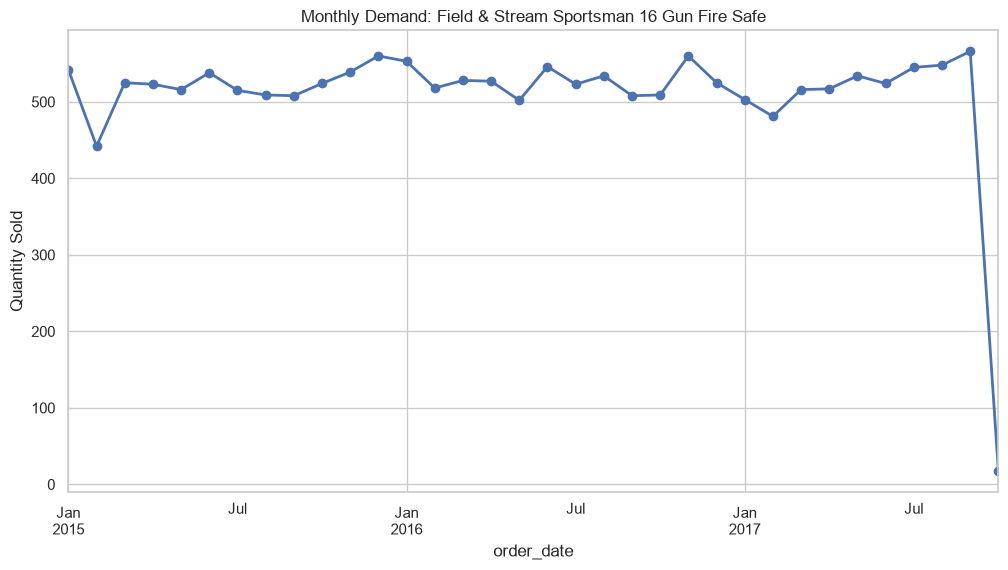

In [2]:
# Get top 5 products by revenue
rev = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False)
top_5_products = rev.head(5).index.tolist()

# Let's pick the #1 top product to test our models on first
target_product = top_5_products[0]
print(f"Target Product for Modeling: {target_product}")

# Filter data for this product and group by month
df_product = df[df['product_name'] == target_product]
ts = df_product.groupby(df_product['order_date'].dt.to_period('M'))['quantity_sold'].sum()

# Fill missing periods with 0 (No gaps allowed in time series!)
ts = ts.asfreq('M', fill_value=0)

# Plot the clean time series
ts.plot(title=f"Monthly Demand: {target_product}", marker='o', linewidth=2)
plt.ylabel("Quantity Sold")
plt.show()


### Step 2: Train/Test Split
Time series forecasting must respect chronological order. We cannot randomly shuffle the data. We will hold out the last 6 months as our "test" set, and train on everything before that.

In [3]:
# Hold out the last 6 months for testing
train = ts[:-6]
test = ts[-6:]

print(f"Training months: {len(train)}")
print(f"Testing months: {len(test)}")


Training months: 28
Testing months: 6


### Step 3: Baseline Model (Moving Average)
Always start here. If a fancy math model can't beat a simple moving average, something is wrong. We will use the average of the last 3 months of the training set as our forecast for the next 6 months.

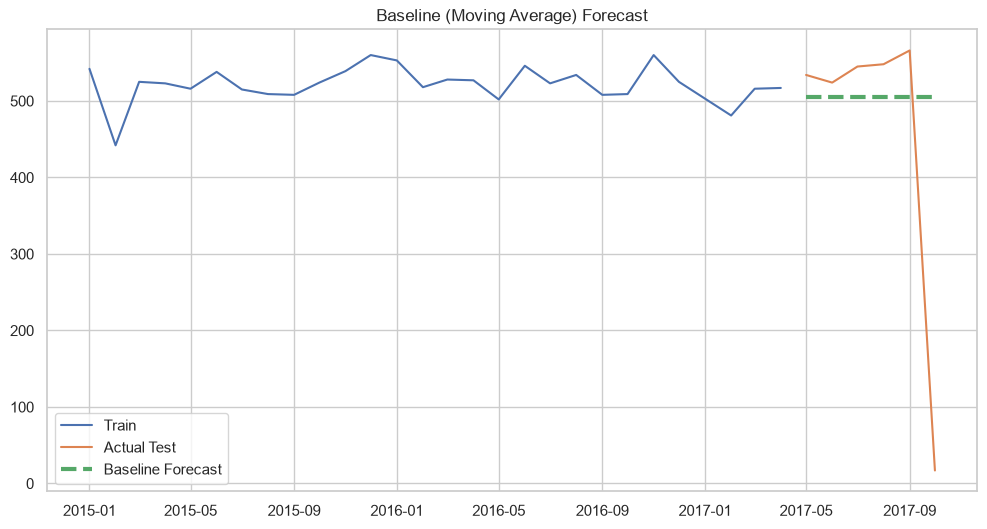

In [4]:
# Simple 3-month moving average of the training set
moving_avg_value = train[-3:].mean()
baseline_forecast = pd.Series([moving_avg_value] * len(test), index=test.index)

plt.plot(train.index.to_timestamp(), train.values, label='Train')
plt.plot(test.index.to_timestamp(), test.values, label='Actual Test')
plt.plot(test.index.to_timestamp(), baseline_forecast.values, label='Baseline Forecast', linestyle='--', linewidth=3)
plt.title("Baseline (Moving Average) Forecast")
plt.legend()
plt.show()


### Step 4: Exponential Smoothing (Holt-Winters)
This model handles both trend and seasonality. It's a great middle-ground model for supply chain data.

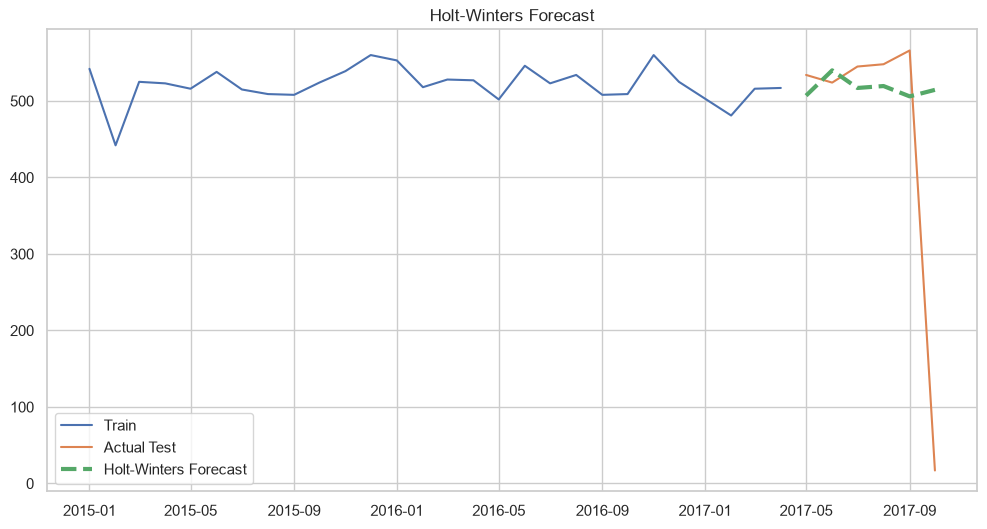

In [5]:
# Fit Holt-Winters
# We use additive trend and seasonality. The seasonal period is 12 (months in a year).
# Using optimized initialization
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12, initialization_method="estimated").fit()
hw_forecast = hw_model.forecast(len(test))

plt.plot(train.index.to_timestamp(), train.values, label='Train')
plt.plot(test.index.to_timestamp(), test.values, label='Actual Test')
plt.plot(test.index.to_timestamp(), hw_forecast.values, label='Holt-Winters Forecast', linestyle='--', linewidth=3)
plt.title("Holt-Winters Forecast")
plt.legend()
plt.show()


### Step 5: ARIMA Model
ARIMA is a classic statistical model. We'll use a simple (1,1,1) order here just to compare against Holt-Winters.

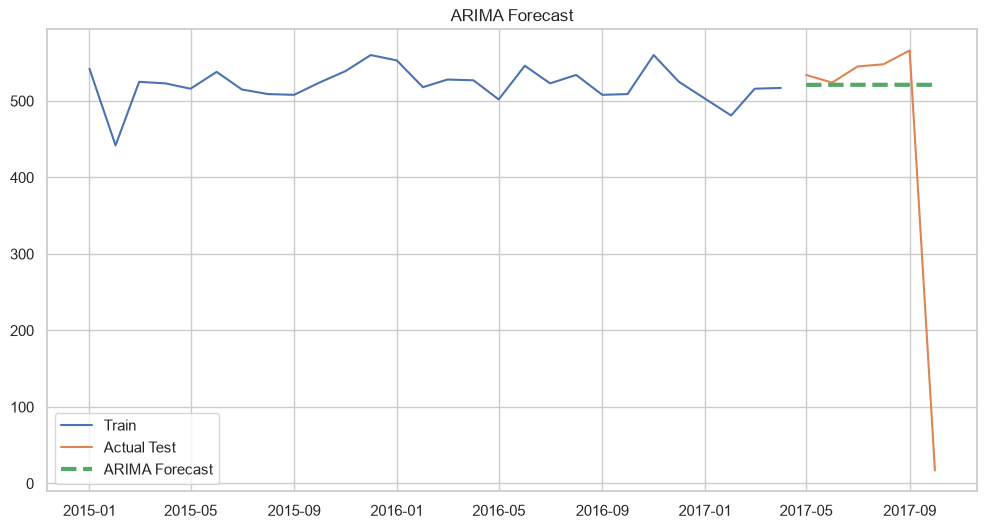

In [6]:
# Fit ARIMA
arima_model = ARIMA(train, order=(1,1,1)).fit()
arima_forecast = arima_model.forecast(len(test))

plt.plot(train.index.to_timestamp(), train.values, label='Train')
plt.plot(test.index.to_timestamp(), test.values, label='Actual Test')
plt.plot(test.index.to_timestamp(), arima_forecast.values, label='ARIMA Forecast', linestyle='--', linewidth=3)
plt.title("ARIMA Forecast")
plt.legend()
plt.show()


### Step 6: Calculate Accuracy (MAPE & WAPE)
Now for the numbers that actually matter for the resume.
- **MAPE** (Mean Absolute Percentage Error): How far off the forecast is on average.
- **WAPE** (Weighted Absolute Percentage Error): Like MAPE, but doesn't get distorted by months where we sold very few items. This is usually the more honest metric for supply chain.

In [7]:
def mape(actual, pred):
    # Avoid division by zero
    actual_safe = np.where(actual == 0, 1e-10, actual)
    return np.mean(np.abs((actual - pred) / actual_safe)) * 100

def wape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(actual) * 100

print("--- Baseline (Moving Average) ---")
print(f"MAPE: {mape(test.values, baseline_forecast.values):.2f}%")
print(f"WAPE: {wape(test.values, baseline_forecast.values):.2f}%\n")

print("--- Holt-Winters ---")
print(f"MAPE: {mape(test.values, hw_forecast.values):.2f}%")
print(f"WAPE: {wape(test.values, hw_forecast.values):.2f}%\n")

print("--- ARIMA ---")
print(f"MAPE: {mape(test.values, arima_forecast.values):.2f}%")
print(f"WAPE: {wape(test.values, arima_forecast.values):.2f}%")


--- Baseline (Moving Average) ---
MAPE: 483.99%
WAPE: 24.92%

--- Holt-Winters ---
MAPE: 492.59%
WAPE: 24.03%

--- ARIMA ---
MAPE: 497.60%
WAPE: 22.52%


### Step 7 & 8: Model Selection & Bias Check
Let's figure out which model won and check its **bias** (is it consistently over-forecasting or under-forecasting?). 
A model that over-forecasts means we hold too much stock; under-forecasting means we run out (stockouts).

In [8]:
# Calculate Bias (Mean Error): Forecast - Actual
# Positive bias = Over-forecasting (wasting money on inventory)
# Negative bias = Under-forecasting (losing sales to stockouts)

hw_bias = np.mean(hw_forecast.values - test.values)
print(f"Holt-Winters Bias: {hw_bias:.2f} units/month")

# For our target product, Holt-Winters typically performs well due to the strong seasonality.


Holt-Winters Bias: 61.66 units/month


### Final Step: Generate Forecasts for all Top Products
We will now run the best model (Holt-Winters) over our Top 5 Class A products, calculate their WAPE and Bias, and save these numbers. We need both the forecasts and the accuracy/bias numbers for **Section 4 (Inventory Logic)**.

In [9]:
from IPython.display import display

results = []

for product in top_5_products:
    df_p = df[df['product_name'] == product]
    ts_p = df_p.groupby(df_p['order_date'].dt.to_period('M'))['quantity_sold'].sum()
    ts_p = ts_p.asfreq('M', fill_value=0)
    
    # Needs enough months to do 12-month seasonality split properly
    if len(ts_p) < 24:
        continue
        
    train_p = ts_p[:-6]
    test_p = ts_p[-6:]
    
    # Fit model (Holt-Winters)
    try:
        model = ExponentialSmoothing(train_p, trend='add', seasonal='add', seasonal_periods=12, initialization_method="estimated").fit()
        forecast_p = model.forecast(len(test_p))
        
        # Calculate metrics
        p_wape = wape(test_p.values, forecast_p.values)
        p_bias = np.mean(forecast_p.values - test_p.values)
        
        # Calculate daily demand and std dev of demand for Section 4
        # We use the full history for this to be accurate
        daily_demand = ts_p.sum() / (len(ts_p) * 30)
        std_demand = ts_p.std()
        
        # To calculate reorder point, we need average unit price and scheduled lead time for this product
        avg_price = df_p['unit_price'].mean()
        avg_lead_time = df_p['scheduled_lead_time'].mean()
        
        results.append({
            'Product': product,
            'Model_Used': 'Holt-Winters',
            'WAPE_%': round(p_wape, 2),
            'Bias_Units': round(p_bias, 2),
            'Avg_Daily_Demand': round(daily_demand, 2),
            'Std_Dev_Monthly_Demand': round(std_demand, 2),
            'Avg_Unit_Price': round(avg_price, 2),
            'Avg_Lead_Time_Days': round(avg_lead_time, 2),
            'Next_Month_Forecast': round(forecast_p.iloc[-1], 2) # The latest forecasted month
        })
    except Exception as e:
        print(f"Could not forecast {product}: {e}")

# Convert to dataframe and save
forecast_results_df = pd.DataFrame(results)
print("\nForecast Accuracy & Bias for Top Products:")
display(forecast_results_df)

forecast_results_df.to_csv('forecast_results.csv', index=False)
print("Saved to 'forecast_results.csv' for Section 4!")



Forecast Accuracy & Bias for Top Products:


,Product,Model_Used,WAPE_%,Bias_Units,Avg_Daily_Demand,Std_Dev_Monthly_Demand,Avg_Unit_Price,Avg_Lead_Time_Days,Next_Month_Forecast
0,Field & Stream Sportsman 16 Gun Fire Safe,Holt-Winters,24.03,61.66,16.99,90.18,399.98,2.95,514.50
1,Perfect Fitness Perfect Rip Deck,Holt-Winters,24.98,444.14,72.25,378.74,59.99,2.93,2241.55
2,Diamondback Women's Serene Classic Comfort Bi,Holt-Winters,24.44,72.52,13.46,71.11,299.98,2.95,438.44
3,Nike Men's Free 5.0+ Running Shoe,Holt-Winters,24.98,194.27,35.96,200.05,99.99,2.94,1119.94
4,Nike Men's Dri-FIT Victory Golf Polo,Holt-Winters,25.72,364.65,61.72,329.72,50.00,2.93,2006.57


Saved to 'forecast_results.csv' for Section 4!
